In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
from matplotlib import *
rcParams['pdf.fonttype']=42 # in order to save fonttype in AI
rcParams['ps.fonttype']=42

In [5]:
# ad_human_neuron.write('Seletti/human_neuron_dealed.h5ad') 之前已经处理过，直接读取
ad_human_neuron = sc.read('Seletti/human_neuron_dealed.h5ad')

In [6]:
# ad_human_glia.write('Seletti/human_glia_dealed.h5ad') 之前已经处理过，直接读取
ad_human_glia = sc.read('Seletti/human_glia_dealed.h5ad')

In [7]:
ad_human = ad_human_glia.concatenate(ad_human_neuron)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_45180\3419141644.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  ad_human = ad_human_glia.concatenate(ad_human_neuron)


In [8]:
monkey = sc.read('data_h5ad/Insular_sorted_clusters.h5ad')

In [9]:
#处理猴子的
monkey = sc.read('data_h5ad/Insular_sorted_clusters.h5ad')
monkey.X = monkey.layers['counts'].copy()
sc.pp.normalize_total(monkey, target_sum=1e4)
sc.pp.log1p(monkey)

In [10]:
monkey.obs['label_main'] = monkey.obs['cellTypeLabel'].copy()

In [11]:
np.unique(monkey.obs['label_main'])

array(['Astrocyte', 'EnVL', 'Exc neuron', 'Inhib neuron', 'Meis2 neuron',
       'Microglia', 'OPC', 'Oligodendrocyte'], dtype=object)

In [12]:
np.unique(monkey.obs['cellTypeLabel'])

array(['Astrocyte', 'EnVL', 'Exc neuron', 'Inhib neuron', 'Meis2 neuron',
       'Microglia', 'OPC', 'Oligodendrocyte'], dtype=object)

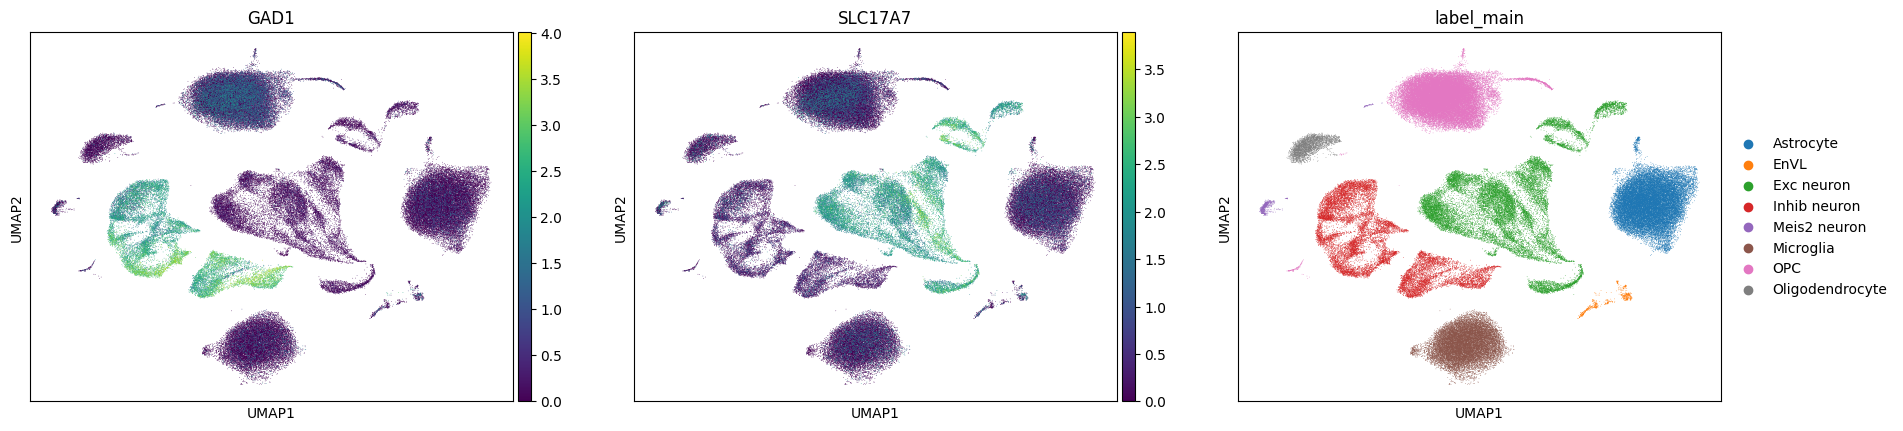

In [13]:
sc.pl.umap(monkey,color=['GAD1','SLC17A7','label_main'])

In [14]:
# 处理另外一个数据集
# reviewer 指定要引用的文章
ad_acc = sc.read('data_processed_all/acc_label_main.h5ad')

In [15]:
# 最后再来一个老鼠的
ad_tasic = sc.read('Tasic2018/Tasic_mice_dealed.h5')

In [16]:
human_acc = ad_acc[ad_acc.obs['orig.ident']=='H',]
monkey_acc = ad_acc[ad_acc.obs['orig.ident']=='M',]
Chimpanzee_acc = ad_acc[ad_acc.obs['orig.ident']=='C',]
Bonobo_acc = ad_acc[ad_acc.obs['orig.ident']=='B',]

In [17]:
rename_dict = dict()
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['Oligodendrocyte precursor']='OPC'
rename_dict['Deep-layer corticothalamic and 6b']='EX'
rename_dict['Deep-layer intratelencephalic']='EX'
rename_dict['Deep-layer near-projecting']='EX'
rename_dict['MGE interneuron']='IN'
rename_dict['CGE interneuron']='IN'
rename_dict['Exc neuron']='EX'
rename_dict['Inhib neuron']='IN'
rename_dict['Oligodendrocyte precursor']='OPC'
rename_dict['Oligodendrocyte precursor']='OPC'
rename_dict['Astro']='Astrocyte'
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['Oligodendrocyte']='Oligo'

In [18]:
human_acc.obs['org']='H_acc'
monkey_acc.obs['org'] = 'M_acc'
Chimpanzee_acc.obs['org']='C_acc'
Bonobo_acc.obs['org']='B_acc'
monkey.obs['org']='M_ins'
ad_human_neuron.obs['org']='H_cor'
ad_human_glia.obs['org']='H_cor'
ad_tasic.obs['org']='M_cor'

C:\Users\Administrator\AppData\Local\Temp\ipykernel_45180\3746558993.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  human_acc.obs['org']='H_acc'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_45180\3746558993.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  monkey_acc.obs['org'] = 'M_acc'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_45180\3746558993.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  Chimpanzee_acc.obs['org']='C_acc'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_45180\3746558993.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  Bonobo_acc.obs['org']='B_acc'


In [19]:
common_gene = human_acc.var_names
for i in [human_acc,monkey_acc,Chimpanzee_acc,Bonobo_acc,monkey,ad_human_neuron,ad_human_glia,ad_tasic]:
    common_gene = common_gene[common_gene.isin(i.var_names)]

In [20]:
for i in [human_acc,monkey_acc,Chimpanzee_acc,Bonobo_acc,monkey,ad_human_neuron,ad_human_glia,ad_tasic]:
    i = i[:,common_gene]

In [21]:
ad = human_acc.concatenate([monkey_acc,Chimpanzee_acc,Bonobo_acc,monkey,ad_human_neuron,ad_human_glia,ad_tasic])

C:\Users\Administrator\AppData\Local\Temp\ipykernel_45180\427619934.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  ad = human_acc.concatenate([monkey_acc,Chimpanzee_acc,Bonobo_acc,monkey,ad_human_neuron,ad_human_glia,ad_tasic])
C:\ProgramData\anaconda3\envs\python_only\Lib\site-packages\anndata\_core\merge.py:1410: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [22]:
ad.obs['label_main'] = ad.obs['label_main'].map(lambda x:rename_dict.get(x,x))

In [23]:
n_hvg = 6000

In [24]:
sc.pp.highly_variable_genes(
    ad,n_top_genes=n_hvg,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

In [25]:
sum(ad.var['highly_variable'])

6000

In [26]:
hvg = ad.var_names[ad.var['highly_variable']].tolist()

In [27]:
# 创建一个字典，把名字和变量映射起来
obs_dict=dict()
obs_dict['H_acc'] = human_acc
obs_dict['M_acc'] = monkey_acc
obs_dict['C_acc'] = Chimpanzee_acc
obs_dict['B_acc'] = Bonobo_acc
obs_dict['M_ins'] = monkey
obs_dict['H_cor'] = ad_human
obs_dict['M_cor'] = ad_tasic

In [28]:
human_acc = human_acc[:,hvg]
monkey_acc = monkey_acc[:,hvg]
Chimpanzee_acc = Chimpanzee_acc[:,hvg]
Bonobo_acc = Bonobo_acc[:,hvg]
monkey = monkey[:,hvg]
ad_human = ad_human[:,hvg]
ad_tasic = ad_tasic[:,hvg]

In [28]:
human_acc

AnnData object with n_obs × n_vars = 6780 × 10506
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'louvain', 'label_main', 'org'
    var: 'name', 'ensmble'
    uns: 'label_main_colors', 'louvain', 'louvain_colors', 'neighbors', 'orig.ident_colors', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

In [29]:
for i in obs_dict.values():
    i.obs['label_main'] = i.obs['label_main'].map(lambda x:rename_dict.get(x,x))
    sc.pp.scale(i,max_value=5)

In [39]:
human_acc

AnnData object with n_obs × n_vars = 6780 × 10506
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'louvain', 'label_main', 'org'
    var: 'name', 'ensmble', 'mean', 'std'
    uns: 'label_main_colors', 'louvain', 'louvain_colors', 'neighbors', 'orig.ident_colors', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

In [31]:
obs_dict.get('M_ins').obs['label_main'].cat.categories

Index(['Astrocyte', 'EnVL', 'EX', 'IN', 'Meis2 neuron', 'Microglia', 'OPC',
       'Oligo'],
      dtype='object')

In [32]:
df = pd.DataFrame(index=hvg)

In [33]:
#for i in ['EX','IN','Astrocyte','Oligo','OPC','Microglia']:
for i in ['EX','IN','Astrocyte','Oligo','OPC','Microglia']:
    for j in ['M_ins','M_acc','H_acc','H_cor','B_acc','C_acc']:
        if i in obs_dict.get(j).obs['label_main'].cat.categories:
            ad_temp = obs_dict.get(j)[:,common_gene]
            #sc.pp.scale(ad_temp,max_value=5)
            df_temp = ad_temp[ad_temp.obs['label_main']==i,].to_df().mean(0)
            df[j+'_'+i] = df_temp

In [34]:
df

,M_ins_EX,M_acc_EX,H_acc_EX,H_cor_EX,B_acc_EX,C_acc_EX,M_ins_IN,M_acc_IN,H_acc_IN,H_cor_IN,...,H_acc_OPC,H_cor_OPC,B_acc_OPC,C_acc_OPC,M_ins_Microglia,M_acc_Microglia,H_acc_Microglia,H_cor_Microglia,B_acc_Microglia,C_acc_Microglia
GCLC,0.069220,-0.008301,-0.035336,-0.050066,0.048134,-0.045951,-0.027355,-0.045667,-0.050514,-0.014177,...,-0.013342,0.027831,-0.081126,0.025062,-0.216539,-0.157960,-0.091866,-0.224921,-0.003284,-0.119139
NFYA,0.023782,-0.026762,-0.033272,-0.006605,-0.007406,-0.023003,-0.095107,-0.088491,-0.042811,-0.036200,...,-0.063020,-0.037564,-0.058211,-0.016370,0.001861,-0.114472,-0.047631,-0.003954,0.007091,-0.062507
NIPAL3,0.101274,0.101550,0.017087,0.059005,0.121286,0.009032,0.022026,-0.113213,0.003445,0.051710,...,-0.049690,-0.091840,-0.223057,-0.127334,-0.141411,-0.129081,-0.145258,-0.359933,-0.241130,-0.100571
LAS1L,0.198517,0.042488,0.134821,0.053440,0.108719,0.051773,0.074664,-0.074025,-0.016868,-0.053599,...,-0.066905,-0.254789,-0.073142,-0.263020,-0.160428,-0.032954,-0.163165,-0.427103,-0.180321,-0.263020
ENPP4,0.131549,-0.011850,0.027459,0.075880,0.037385,0.004613,-0.024340,-0.013259,-0.006350,-0.095161,...,-0.058140,-0.086296,-0.122989,-0.053447,-0.422645,-0.013259,-0.184990,-0.480129,-0.193644,-0.099925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SSTR3,-0.002333,0.083113,-0.024831,0.044190,-0.011146,0.000000,-0.026242,-0.160566,-0.041460,-0.130710,...,-0.032537,-0.205015,-0.016523,0.000000,-0.027777,-0.008013,-0.048116,-0.200538,-0.016523,0.000000
MYO19,-0.022388,0.008921,0.032265,0.041879,-0.057713,0.005496,-0.019855,0.001403,-0.029615,0.093754,...,-0.087588,-0.315059,-0.100407,-0.076159,-0.051814,-0.002487,-0.087971,-0.306044,-0.058887,-0.148676
GGNBP2,0.430515,0.046302,0.145153,0.126950,0.270878,0.057262,0.361479,0.002175,-0.030172,-0.046537,...,-0.117328,-0.436320,-0.252513,-0.080630,-0.359992,-0.118645,0.004467,-0.112826,-0.084588,-0.085225
DHRS11,0.240982,0.041575,0.045963,0.042132,0.306966,0.077868,0.163667,-0.020251,-0.040721,0.041049,...,-0.098261,-0.305409,-0.204865,-0.217677,-0.250844,0.044169,-0.114044,-0.372854,-0.222875,-0.120478


In [35]:
ad.shape

(286163, 9426)

In [36]:
plot_data = df.corr()

<Axes: >

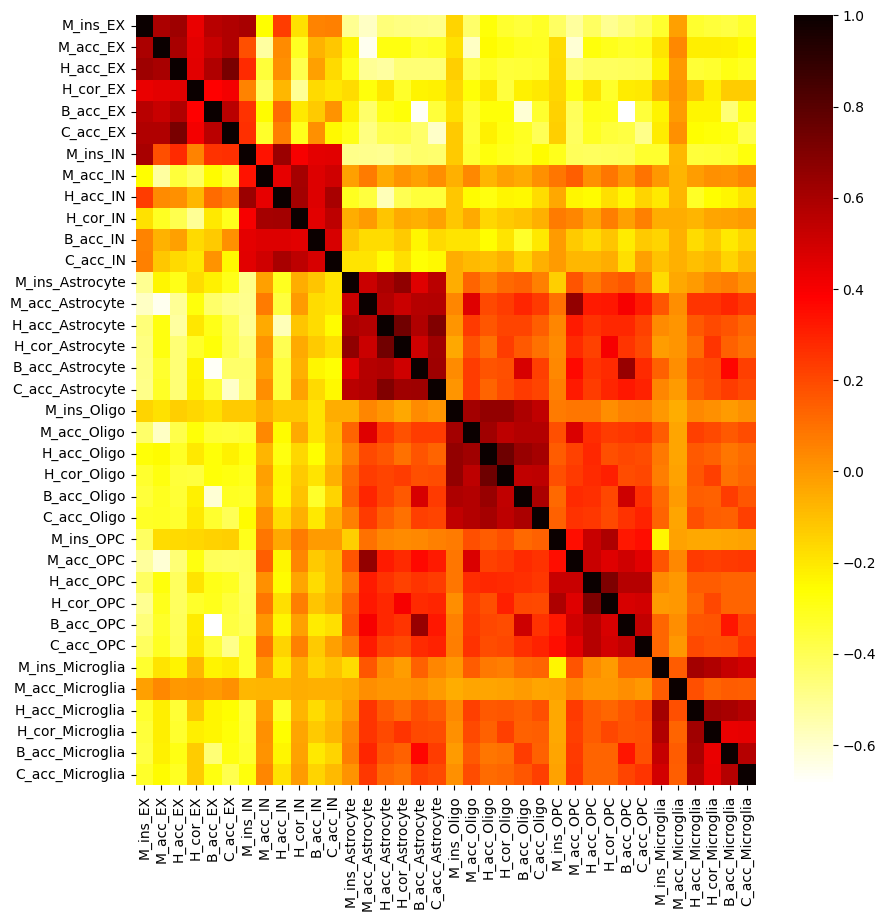

In [37]:
plt.figure(figsize=(10, 10)) 
sns.heatmap(plot_data,cmap='hot_r',)

<Figure size 500x500 with 0 Axes>

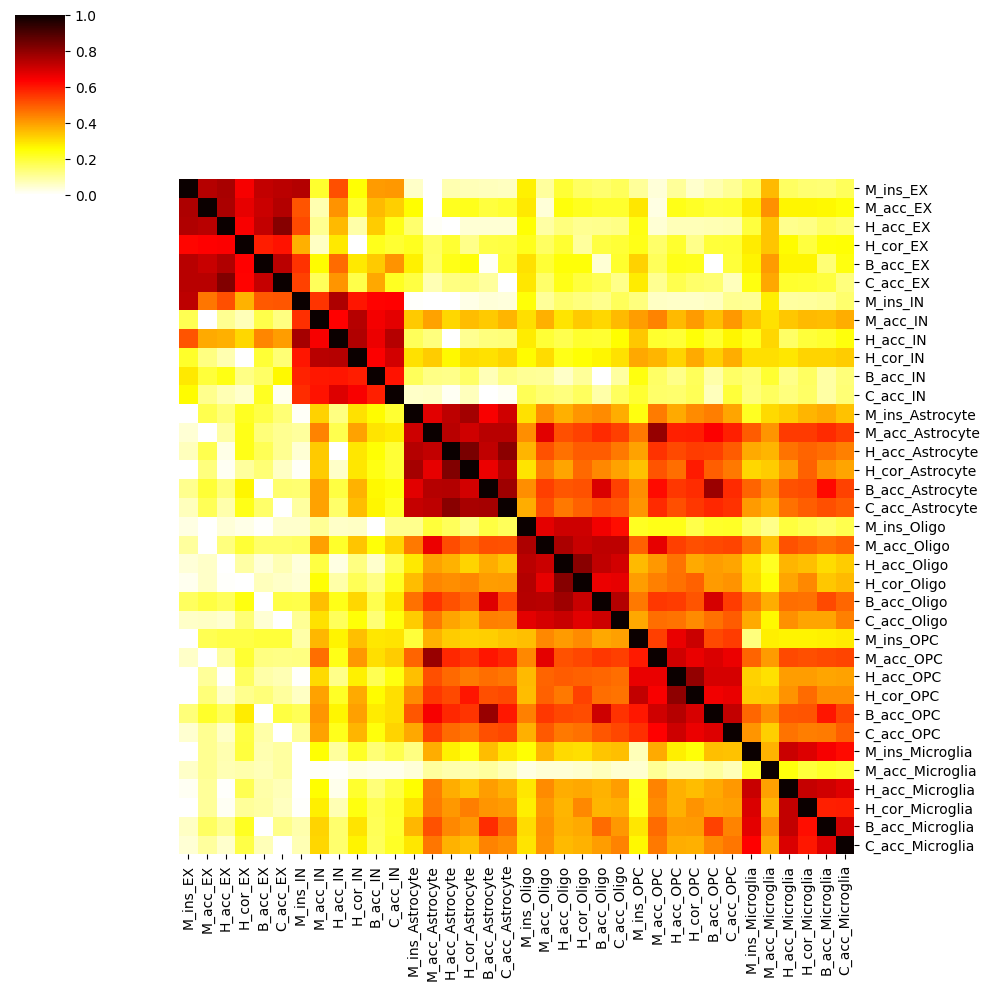

In [38]:
plt.figure(figsize=(5, 5)) 
sns.clustermap(plot_data,cmap='hot_r',standard_scale=0,row_cluster=False,col_cluster=False,figsize=(10,10))
#plt.savefig(f'Figures/cross_species_heatmap_{n_hvg}.pdf')
plt.savefig(f'Figures/cross_species_heatmap_ALL_gene.pdf')